# Pilot vs. full study — same question, better baseline

The **pilot** (8 names, 960 forecasts, `probe_findings.ipynb`) compared Kronos
only to EWMA and looked promising. The **full study** (30 names, 11,340
forecasts, `02_vol_forecast_eval.ipynb`) added a properly-specified,
walk-forward **HAR-RV** baseline — the model actually built for this problem —
and the promising result didn't survive contact with it.

Three basic charts, same story each time: **more rigor, smaller edge.**


In [1]:
import os
if "src" not in os.listdir("."):
    os.chdir("..")

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

def qlike(f, r):
    f2, r2 = np.asarray(f, float)**2 + 1e-12, np.asarray(r, float)**2 + 1e-12
    return float(np.mean(r2/f2 - np.log(r2/f2) - 1))

pilot = pd.read_pickle("research/probe_hourly_rv/data/probe_results.pkl")
full  = pd.read_parquet("store/panel_hourly_H1_gk.parquet")
print(f"pilot: {len(pilot):,} forecasts, {pilot.ticker.nunique()} names")
print(f"full:  {len(full):,} forecasts, {full.ticker.nunique()} names")

pilot: 960 forecasts, 8 names
full:  11,340 forecasts, 30 names


## 1 · QLIKE by model, relative to EWMA

The pilot and full study used slightly different RV estimators (naive
close-to-close vs. Garman–Klass), so raw QLIKE isn't comparable across the two —
only the within-study ranking is. Normalising each panel to its own EWMA puts
both on the same axis: **below 1.0 beats EWMA, above 1.0 loses to it.**

The pilot's own HAR implementation was a quick, badly-behaved walk-forward fit
(QLIKE in the thousands) — excluded here rather than shown broken. The full
study's HAR is the real thing.

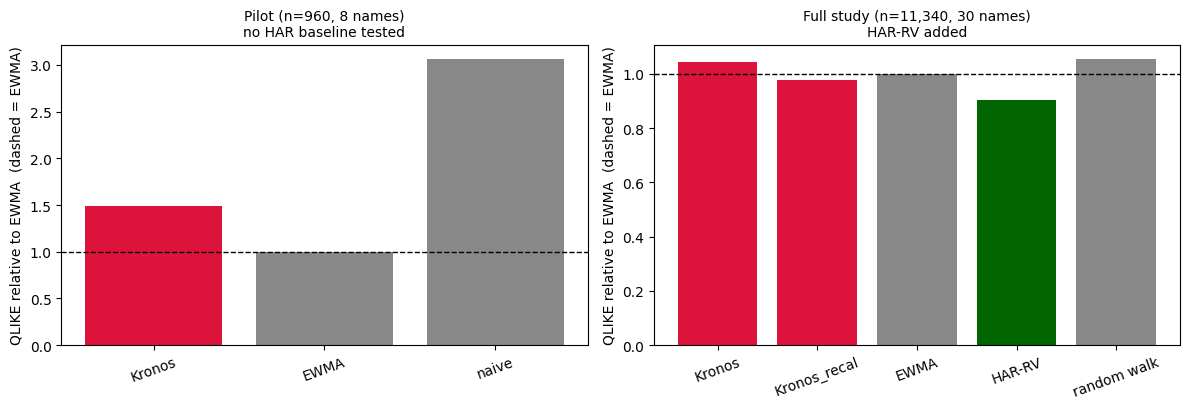

In [3]:
pilot_scores = {
    "Kronos":  qlike(pilot["kronos"], pilot["realized"]),
    "EWMA":    qlike(pilot["ewma"],   pilot["realized"]),
    "naive":   qlike(pilot["naive"],  pilot["realized"]),
}
full_scores = {
    "Kronos":       qlike(full["kronos"],       full["realised"]),
    "Kronos_recal": qlike(full["kronos_recal"], full["realised"]),
    "EWMA":         qlike(full["ewma94"],       full["realised"]),
    "HAR-RV":       qlike(full["har"],          full["realised"]),
    "random walk":  qlike(full["rw"],           full["realised"]),
}
pilot_rel = {k: v / pilot_scores["EWMA"] for k, v in pilot_scores.items()}
full_rel  = {k: v / full_scores["EWMA"]  for k, v in full_scores.items()}

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))   # separate y-scales: the pilot's
for a, scores, title in [(ax[0], pilot_rel, f"Pilot (n={len(pilot):,}, 8 names)\nno HAR baseline tested"),
                          (ax[1], full_rel,  f"Full study (n={len(full):,}, 30 names)\nHAR-RV added")]:
    names = list(scores); vals = [scores[k] for k in names]
    colors = ["crimson" if "Kronos" in k else ("darkgreen" if "HAR" in k else "#888") for k in names]
    a.bar(names, vals, color=colors)
    a.axhline(1.0, c="k", lw=1, ls="--")
    a.set_ylabel("QLIKE relative to EWMA  (dashed = EWMA)")
    a.set_title(title, fontsize=10); a.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

In the pilot, Kronos sits close to the EWMA line — roughly competitive.
Once HAR-RV is tested properly, it drops clearly *below* the line and every
Kronos variant sits *above* it: HAR beats everything else outright, Kronos
included.

## 2 · Incremental R² — the edge shrinks as the bar gets harder

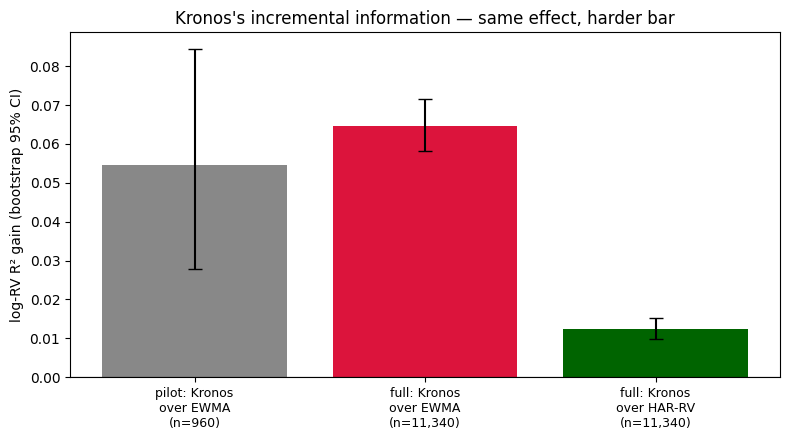

pilot: Kronos                over EWMA      gain +0.055  CI [+0.028, +0.084]
full: Kronos                 over EWMA      gain +0.065  CI [+0.058, +0.071]
full: Kronos                 over HAR-RV    gain +0.012  CI [+0.010, +0.015]


In [4]:
def inc_r2(df, add, base, realized_col):
    d = df.dropna(subset=[add, base, realized_col])
    y = np.log(d[realized_col].clip(lower=1e-9))
    def r2(X):
        c, *_ = np.linalg.lstsq(X, y, rcond=None)
        e = y - X @ c
        return 1 - (e**2).sum() / ((y - y.mean())**2).sum()
    Xb = np.c_[np.ones(len(d)), np.log(d[base].clip(lower=1e-9))]
    Xba = np.c_[Xb, np.log(d[add].clip(lower=1e-9))]
    return r2(Xba) - r2(Xb)

def boot_ci(df, add, base, realized_col, n_boot=1500, seed=0):
    rng = np.random.default_rng(seed)
    idx = df.dropna(subset=[add, base, realized_col]).index.to_numpy()
    gains = [inc_r2(df.loc[rng.choice(idx, len(idx), replace=True)], add, base, realized_col)
             for _ in range(n_boot)]
    return np.mean(gains), *np.percentile(gains, [2.5, 97.5])

bars = [
    ("pilot: Kronos\nover EWMA\n(n=960)",       *boot_ci(pilot, "kronos", "ewma", "realized")),
    ("full: Kronos\nover EWMA\n(n=11,340)",      *boot_ci(full, "kronos", "ewma94", "realised")),
    ("full: Kronos\nover HAR-RV\n(n=11,340)",    *boot_ci(full, "kronos", "har", "realised")),
]
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(bars))
means = [b[1] for b in bars]; los = [b[1]-b[2] for b in bars]; his = [b[3]-b[1] for b in bars]
ax.bar(x, means, color=["#888", "crimson", "darkgreen"])
ax.errorbar(x, means, yerr=[los, his], fmt="none", ecolor="k", capsize=5)
ax.axhline(0, c="k", lw=.8)
ax.set_xticks(x); ax.set_xticklabels([b[0] for b in bars], fontsize=9)
ax.set_ylabel("log-RV R² gain (bootstrap 95% CI)")
ax.set_title("Kronos's incremental information — same effect, harder bar")
plt.tight_layout(); plt.show()
for label, mean, lo, hi in bars:
    print(f"{label.splitlines()[0]:28s} {label.splitlines()[1]:14s} gain {mean:+.3f}  CI [{lo:+.3f}, {hi:+.3f}]")

The gain over EWMA replicates (pilot +0.05, full +0.065, both CIs clear
of zero). But that was always the wrong comparison. Against HAR-RV — the model
that actually wins — Kronos's contribution drops to **+0.013**. Real, CI still
excludes zero, but an order of magnitude short of "beats the baseline."


## 3 · What changed between the two studies

The two studies asked the same question at very different rigor. Scale and the
addition of a real HAR-RV baseline are the whole difference in the verdict.

In [5]:
summary = pd.DataFrame({
    "pilot":       {"names": 8,  "forecasts": len(pilot), "baselines": "EWMA, naive",
                    "HAR-RV tested?": "attempted, broken", "winner": "Kronos ≈ EWMA"},
    "full study":  {"names": 30, "forecasts": len(full),  "baselines": "EWMA, rolling, HAR-RV, GARCH, GJR, RW",
                    "HAR-RV tested?": "yes, walk-forward", "winner": "HAR-RV"},
}).T
summary

,names,forecasts,baselines,HAR-RV tested?,winner
pilot,8,960,"EWMA, naive","attempted, broken",Kronos ≈ EWMA
full study,30,11340,"EWMA, rolling, HAR-RV, GARCH, GJR, RW","yes, walk-forward",HAR-RV


---
## Bottom line

Both studies find the same underlying signal — Kronos ranks near-term
volatility a bit better than a plain EWMA. What changes is the verdict, because
the pilot never tested the model that was actually going to win. **Against a
properly-specified HAR-RV, Kronos-small does not beat baseline methods** for
equity volatility forecasting. That holds however you cut it: raw, recalibrated,
alone, or blended in. Full detail in `02_vol_forecast_eval.ipynb`.
